
Тепловая карта показывает, какие частоты (мел-бины) и временные участки спектрограммы модель использует при классификации.

In [17]:
import sys
sys.path.append('/workspaces/super-duper-dollop')
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch.utils.data import DataLoader

from src.models.VoiceResNet import VoiceResNet
from src.data.speaker_dataset import LogMel_Dataset

## Загрузка модели и датасета

In [18]:
CKPT_PATH  = '/workspaces/super-duper-dollop/best_voiceresnet.pt'
DATA_PATH  = '/workspaces/super-duper-dollop/data/processed/test_dataset.parquet'
N_SAMPLES  = 6   # сколько примеров визуализировать

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = VoiceResNet(dropout=0.3).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device, weights_only=True))
model.eval()
print('Model loaded')

ds = LogMel_Dataset(DATA_PATH, augmentations=False, max_length=5.0, device=device)
loader = DataLoader(ds, batch_size=1, shuffle=True)
print(f'Test samples: {len(ds)}')

Model loaded
Loading precomputed LogMels from disk...
Test samples: 79


## GradCAM

In [ ]:
class GradCAM:
    def __init__(self, model: torch.nn.Module, target_layer: torch.nn.Module):
        self.model = model
        self._activations = None
        self._gradients   = None

        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self._activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self._gradients = grad_output[0].detach()

    def __call__(self, x: torch.Tensor) -> tuple[np.ndarray, float]:
        self.model.zero_grad()
        logit = self.model(x)            # [1, 1]
        logit.backward()

        weights = self._gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]
        cam = (weights * self._activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = F.relu(cam)

        H, W = x.shape[-2], x.shape[-1]
        cam = F.interpolate(cam, size=(H, W), mode='bilinear', align_corners=True)
        cam = cam.squeeze().cpu().numpy()

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        prob = torch.sigmoid(logit).item()
        return cam, prob


gradcam = GradCAM(model, target_layer=model.layer3)
print('GradCAM ready — target layer: layer3')

GradCAM ready — target layer: layer3


## Визуализация

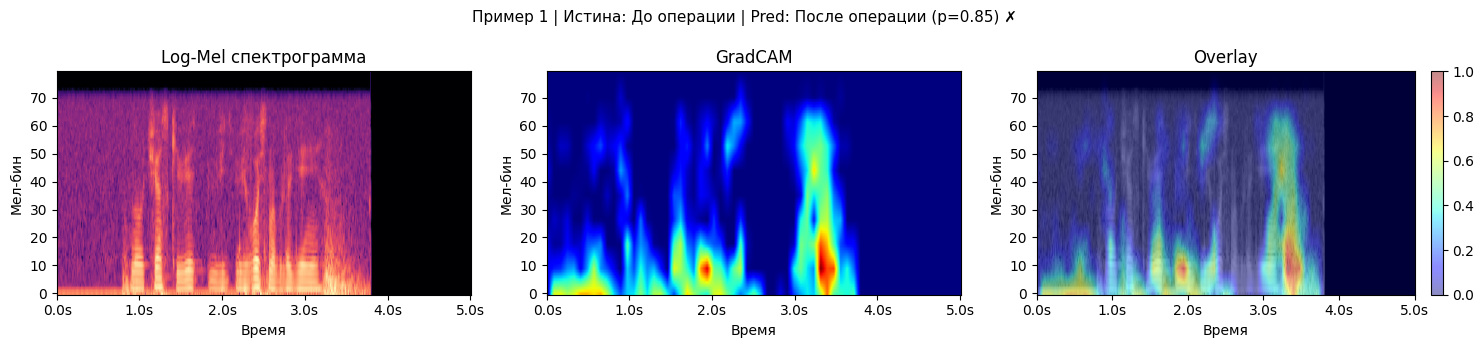

Сохранено: gradcam_sample_1.png


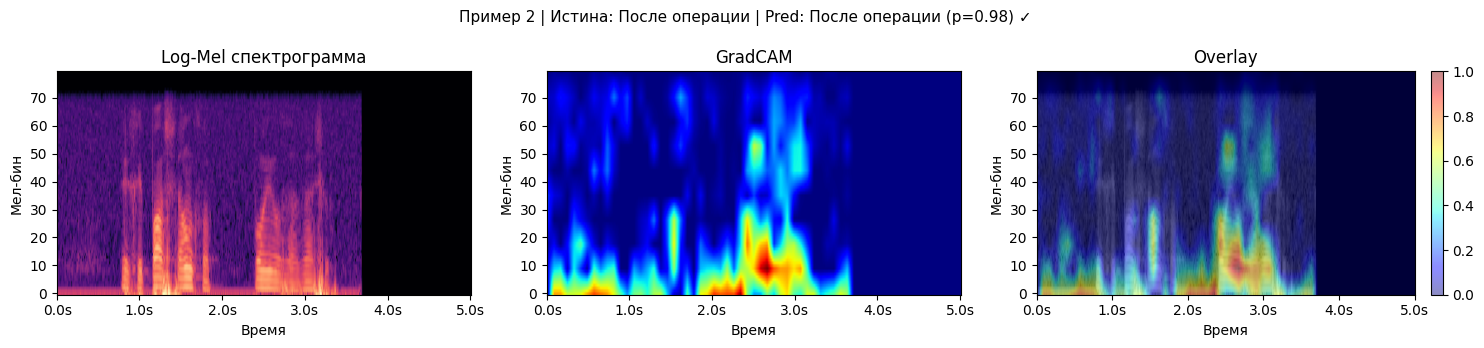

Сохранено: gradcam_sample_2.png


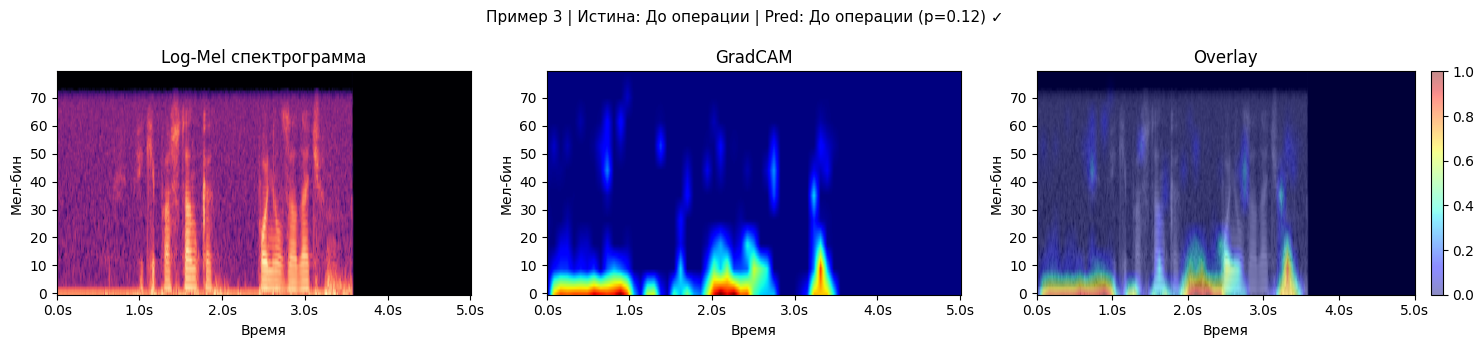

Сохранено: gradcam_sample_3.png


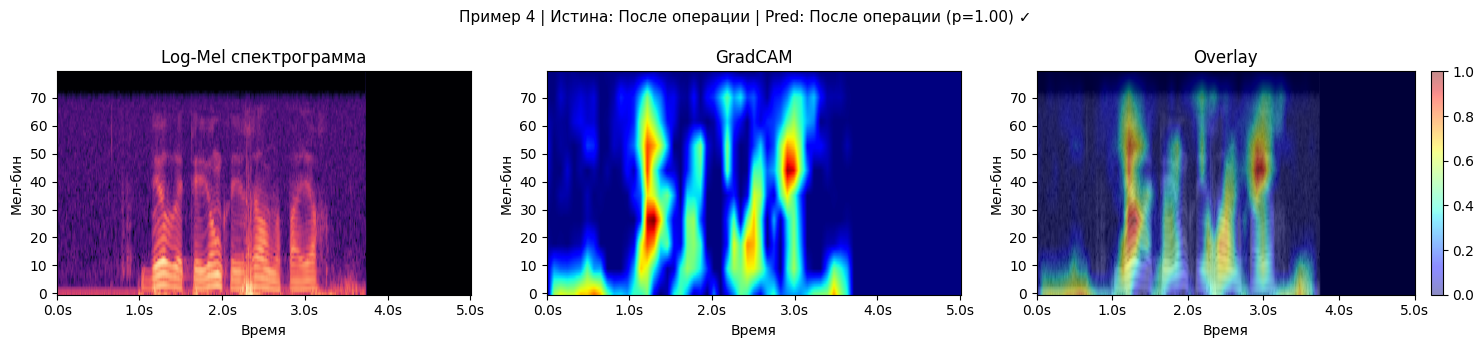

Сохранено: gradcam_sample_4.png


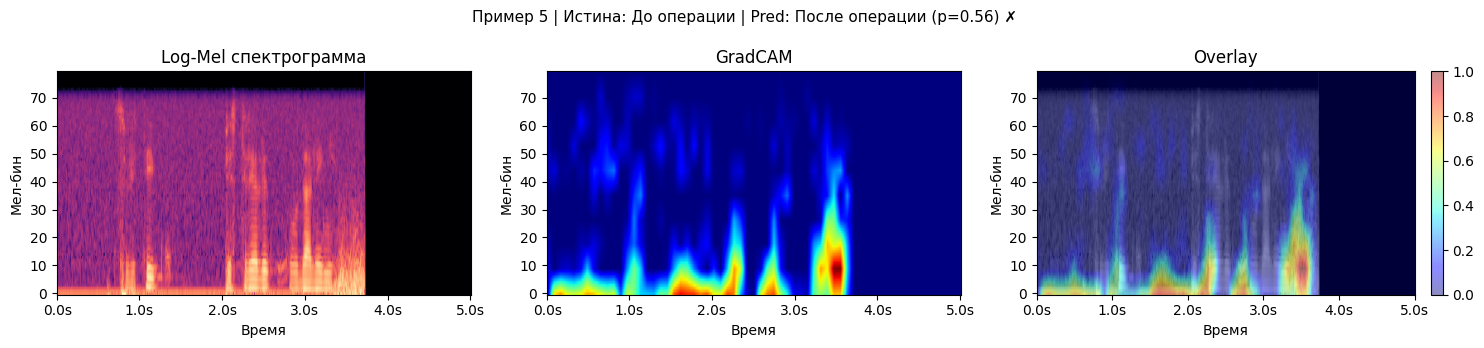

Сохранено: gradcam_sample_5.png


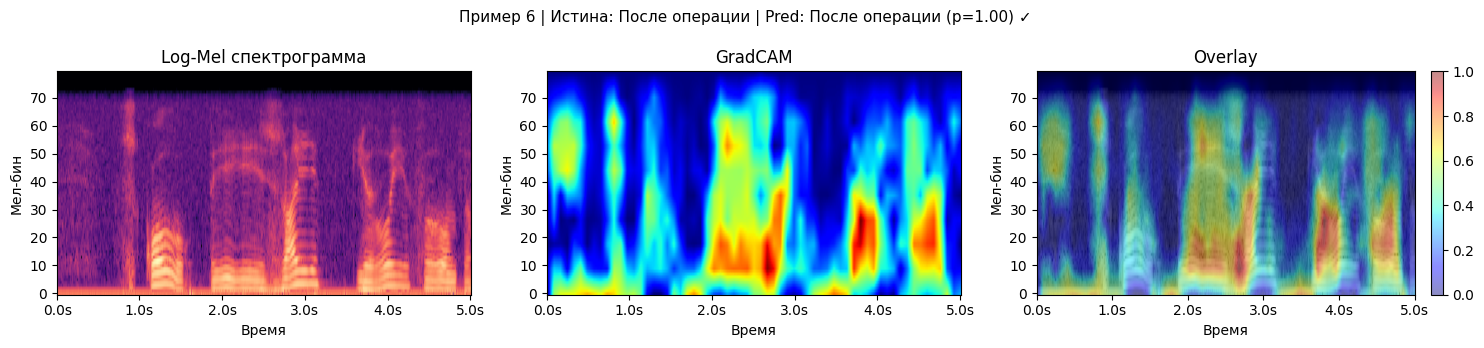

Сохранено: gradcam_sample_6.png


In [ ]:
CLASS_NAMES = {0: "До операции", 1: "После операции"}
HOP_MS = 10 
N_PER_CLASS = 3

samples = {0: [], 1: []}
for x, label in loader:
    cls = int(label.item())
    if len(samples[cls]) < N_PER_CLASS:
        samples[cls].append((x, cls))
    if all(len(v) == N_PER_CLASS for v in samples.values()):
        break

pairs = [s for pair in zip(samples[0], samples[1]) for s in pair]

for i, (x, true_cls) in enumerate(pairs):
    x = x.to(device).requires_grad_(True)  # [1, 1, 80, 500]

    cam, prob = gradcam(x)
    pred_cls = int(prob > 0.5)
    correct = pred_cls == true_cls

    spec = x.squeeze().detach().cpu().numpy()  # [80, 500]
    spec_norm = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)

    n_frames = spec.shape[1]
    xticks_frames = np.linspace(0, n_frames - 1, 6).astype(int)
    xtick_labels = [f"{t * HOP_MS / 1000:.1f}s" for t in xticks_frames]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    fig.suptitle(
        f"Пример {i + 1} | Истина: {CLASS_NAMES[true_cls]} | "
        f"Pred: {CLASS_NAMES[pred_cls]} (p={prob:.2f}) {'✓' if correct else '✗'}",
        fontsize=11,
    )

    axes[0].imshow(spec, origin="lower", aspect="auto", cmap="magma")
    axes[0].set_title("Log-Mel спектрограмма")
    axes[0].set_ylabel("Мел-бин")
    axes[0].set_xticks(xticks_frames)
    axes[0].set_xticklabels(xtick_labels)
    axes[0].set_xlabel("Время")

    axes[1].imshow(cam, origin="lower", aspect="auto", cmap="jet")
    axes[1].set_title("GradCAM")
    axes[1].set_ylabel("Мел-бин")
    axes[1].set_xticks(xticks_frames)
    axes[1].set_xticklabels(xtick_labels)
    axes[1].set_xlabel("Время")

    axes[2].imshow(spec_norm, origin="lower", aspect="auto", cmap="gray")
    im = axes[2].imshow(cam, origin="lower", aspect="auto", cmap="jet", alpha=0.45)
    axes[2].set_title("Overlay")
    axes[2].set_ylabel("Мел-бин")
    axes[2].set_xticks(xticks_frames)
    axes[2].set_xticklabels(xtick_labels)
    axes[2].set_xlabel("Время")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f"gradcam_sample_{i + 1}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {fname}")


## SE-веса: какие каналы модель усиливает

SE-блок вычисляет скаляр на канал — смотрим, что в среднем по тестовой выборке.

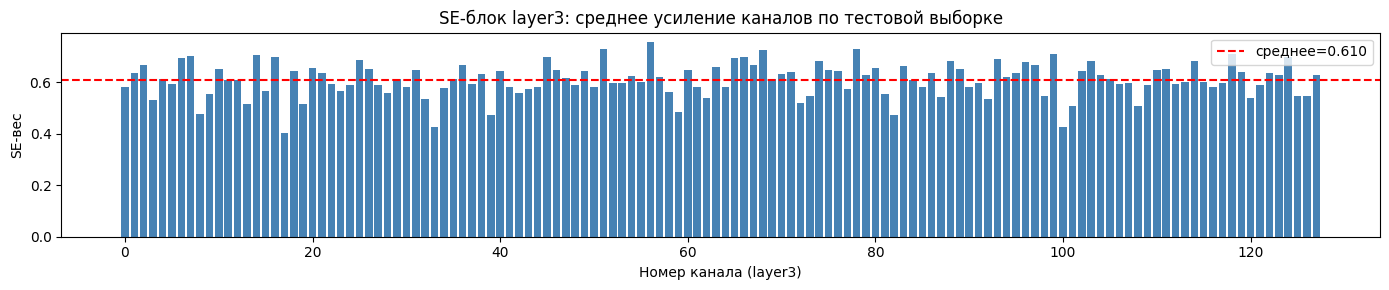

Сохранено: se_weights.png


In [ ]:
se_weights_all = []


def make_hook(storage):
    def hook(module, inp, out):
        x_in = inp[0]
        b, c, _, _ = x_in.size()
        w = module.pool(x_in).view(b, c)
        w = module.fc(w)
        storage.append(w.detach().cpu())

    return hook


h = model.layer3[0].se.register_forward_hook(make_hook(se_weights_all))

with torch.no_grad():
    for x, _ in loader:
        model(x.to(device))

h.remove()

se_mean = torch.cat(se_weights_all, dim=0).mean(dim=0).numpy()  # [128]

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(len(se_mean)), se_mean, color="steelblue")
ax.axhline(
    se_mean.mean(), color="red", linestyle="--", label=f"среднее={se_mean.mean():.3f}"
)
ax.set_xlabel("Номер канала (layer3)")
ax.set_ylabel("SE-вес")
ax.set_title("SE-блок layer3: среднее усиление каналов по тестовой выборке")
ax.legend()
plt.tight_layout()
plt.savefig("se_weights.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: se_weights.png")